Loading MNIST using sklearn...


C:\Users\User\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Successfully loaded MNIST using sklearn
Training data shape: (60000, 784)
Test data shape: (10000, 784)
Data Statistics - Mean: 0.1307, Std: 0.3081

Training with ReLU activation...
Epoch 1/5:
  Loss: 0.2584, Accuracy: 0.9233
Epoch 2/5:
  Loss: 0.1257, Accuracy: 0.9631
Epoch 3/5:
  Loss: 0.0918, Accuracy: 0.9729
Epoch 4/5:
  Loss: 0.0724, Accuracy: 0.9792
Epoch 5/5:
  Loss: 0.0591, Accuracy: 0.9828

Test Accuracy: 0.9740


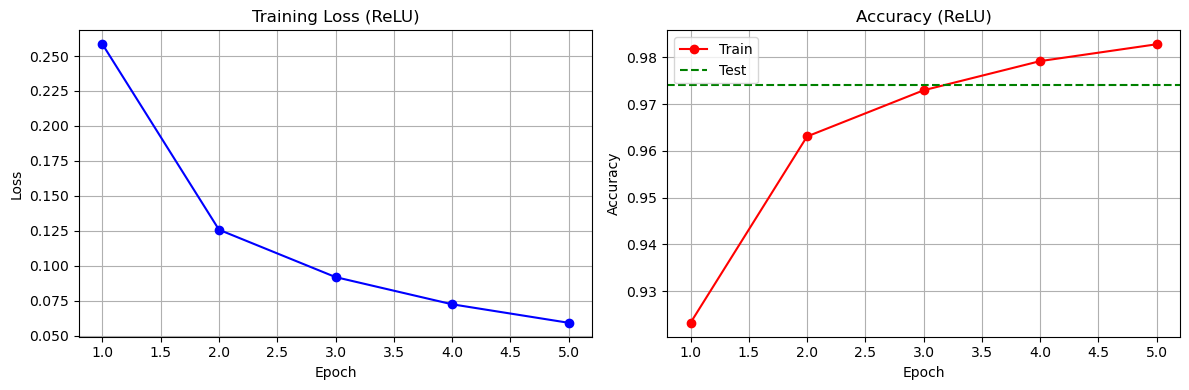


=== FINAL RESULTS WITH ReLU ACTIVATION ===
Data Statistics:
  Mean pixel value: 0.1307
  Standard deviation: 0.3081

Training Performance:
  Epoch 1: Loss = 0.2584, Train Acc = 0.9233
  Epoch 2: Loss = 0.1257, Train Acc = 0.9631
  Epoch 3: Loss = 0.0918, Train Acc = 0.9729
  Epoch 4: Loss = 0.0724, Train Acc = 0.9792
  Epoch 5: Loss = 0.0591, Train Acc = 0.9828
Final Test Accuracy: 0.9740


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import urllib.request
import gzip
import os

def load_mnist_sklearn():
    """Load MNIST using sklearn (no torch required)"""
    print("Loading MNIST using sklearn...")
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
    X, y = mnist.data, mnist.target.astype(int)
    
    # Split into train and test (standard MNIST split)
    X_train = X[:60000] / 255.0
    y_train = y[:60000]
    X_test = X[60000:] / 255.0
    y_test = y[60000:]
    
    return X_train, y_train, X_test, y_test

def load_mnist_manual():
    """Manual download and load of MNIST"""
    print("Downloading MNIST manually...")
    
    # URLs for MNIST dataset
    urls = [
        'http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz',
        'http://yann.lecun.com/exdb/mnist/train-labels-idx1-ubyte.gz',
        'http://yann.lecun.com/exdb/mnist/t10k-images-idx3-ubyte.gz',
        'http://yann.lecun.com/exdb/mnist/t10k-labels-idx1-ubyte.gz'
    ]
    
    files = []
    for url in urls:
        filename = url.split('/')[-1]
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
        files.append(filename)
    
    # Load training images
    with gzip.open(files[0], 'rb') as f:
        f.read(16)  # skip header
        X_train = np.frombuffer(f.read(), dtype=np.uint8).reshape(-1, 784)
    
    # Load training labels
    with gzip.open(files[1], 'rb') as f:
        f.read(8)  # skip header
        y_train = np.frombuffer(f.read(), dtype=np.uint8)
    
    # Load test images
    with gzip.open(files[2], 'rb') as f:
        f.read(16)  # skip header
        X_test = np.frombuffer(f.read(), dtype=np.uint8).reshape(-1, 784)
    
    # Load test labels
    with gzip.open(files[3], 'rb') as f:
        f.read(8)  # skip header
        y_test = np.frombuffer(f.read(), dtype=np.uint8)
    
    return X_train / 255.0, y_train, X_test / 255.0, y_test

# Try to load data
try:
    X_train, y_train, X_test, y_test = load_mnist_sklearn()
    print("Successfully loaded MNIST using sklearn")
except Exception as e:
    print(f"Sklearn method failed: {e}")
    print("Trying manual download...")
    X_train, y_train, X_test, y_test = load_mnist_manual()
    print("Successfully loaded MNIST manually")

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# Normalize data
train_mean = np.mean(X_train)
train_std = np.std(X_train)
X_train_normalized = (X_train - train_mean) / train_std
X_test_normalized = (X_test - train_mean) / train_std

print(f"Data Statistics - Mean: {train_mean:.4f}, Std: {train_std:.4f}")

# Convert labels to one-hot encoding
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

# Network parameters
d = 784  # input dimension
h = 128  # hidden units
k = 10   # output classes

# Initialize weights with He initialization for ReLU
W1 = np.random.randn(h, d) * np.sqrt(2.0 / d)
W2 = np.random.randn(k, h) * np.sqrt(2.0 / h)

# Activation functions
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(np.float32)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=0, keepdims=True))
    return exp_x / np.sum(exp_x, axis=0, keepdims=True)

# Training parameters
learning_rate = 1e-3
batch_size = 1
epochs = 5

# Storage for metrics
train_losses = []
train_accuracies = []

print("\nTraining with ReLU activation...")
for epoch in range(epochs):
    epoch_loss = 0
    epoch_correct = 0
    num_batches = 0
    
    # Shuffle training data
    indices = np.random.permutation(len(X_train_normalized))
    X_epoch = X_train_normalized[indices]
    y_epoch = y_train_onehot[indices]
    y_labels_epoch = y_train[indices]
    
    for i in range(0, len(X_epoch), batch_size):
        x = X_epoch[i].reshape(-1, 1)
        y = y_epoch[i].reshape(-1, 1)
        y_label = y_labels_epoch[i]
        
        # Forward pass
        a1 = W1 @ x
        h1 = relu(a1)
        a2 = W2 @ h1
        y_hat = softmax(a2)
        
        # Compute loss and accuracy
        loss = -np.sum(y * np.log(y_hat + 1e-8))
        epoch_loss += loss
        predicted_class = np.argmax(y_hat)
        if predicted_class == y_label:
            epoch_correct += 1
        
        # Backward pass
        delta2 = y_hat - y
        dW2 = delta2 @ h1.T
        
        delta_h = W2.T @ delta2
        relu_deriv = relu_derivative(a1)
        delta1 = delta_h * relu_deriv
        dW1 = delta1 @ x.T
        
        # Update weights
        W2 -= learning_rate * dW2
        W1 -= learning_rate * dW1
        
        num_batches += 1
    
    # Epoch statistics
    avg_loss = epoch_loss / num_batches
    accuracy = epoch_correct / num_batches
    
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    
    print(f"Epoch {epoch+1}/{epochs}:")
    print(f"  Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

# Test accuracy
test_correct = 0
for i in range(len(X_test_normalized)):
    x = X_test_normalized[i].reshape(-1, 1)
    y_label = y_test[i]
    
    a1 = W1 @ x
    h1 = relu(a1)
    a2 = W2 @ h1
    y_hat = softmax(a2)
    
    predicted_class = np.argmax(y_hat)
    if predicted_class == y_label:
        test_correct += 1

test_accuracy = test_correct / len(X_test_normalized)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, 'b-o')
plt.title('Training Loss (ReLU)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, 'r-o', label='Train')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test')
plt.title('Accuracy (ReLU)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Final summary
print("\n=== FINAL RESULTS WITH ReLU ACTIVATION ===")
print(f"Data Statistics:")
print(f"  Mean pixel value: {train_mean:.4f}")
print(f"  Standard deviation: {train_std:.4f}")
print(f"\nTraining Performance:")
for epoch in range(epochs):
    print(f"  Epoch {epoch+1}: Loss = {train_losses[epoch]:.4f}, Train Acc = {train_accuracies[epoch]:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")